<a href="https://colab.research.google.com/github/Squad-Dorothy-Vaughan/Challenge-Correlacao-Regressao/blob/main/%5BOFICIAL%5D_Challenge_Correla%C3%A7%C3%A3o_e_Regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

url = 'https://raw.githubusercontent.com/Squad-Dorothy-Vaughan/Challenge-Correlacao-Regressao/refs/heads/main/desafio_carros_usados.csv'
df_carros = pd.read_csv(url)

df_carros = df_carros.rename(columns={
    'id': 'id',
    'make': 'marca',
    'model': 'modelo',
    'year': 'ano',
    'price': 'preco',
    'mileage': 'quilometragem',
    'engine_size': 'tamanho_motor',
    'fuel_type': 'tipo_combustivel',
    'transmission': 'transmissao',
    'doors': 'portas',
    'color': 'cor',
    'tax': 'imposto',
    'mpg': 'consumo_mpg',
    'sold_date': 'data_venda'
})

display(df_carros.head(10))

,id,marca,modelo,ano,preco,quilometragem,tamanho_motor,tipo_combustivel,transmissao,portas,cor,imposto,consumo_mpg,data_venda
0,1,Volkswagen,Model B,2022,23859,94811,3.6,Diesel,Manual,2,Grey,288,39.2,2023-10-11
1,2,Chevrolet,Model A,2008,16953,128028,4.9,Diesel,Manual,5,Red,339,15.3,2021-04-22
2,3,BMW,Model B,2006,12332,49178,4.1,Diesel,Automatic,4,Red,458,37.2,2020-05-04
3,4,Chevrolet,Model B,2018,18475,42821,2.7,Hybrid,Manual,5,Silver,486,43.7,2021-06-20
4,5,Chevrolet,Model C,2017,12129,192799,2.8,Gasoline,Manual,4,Silver,295,19.1,2021-12-06
5,6,Toyota,Model D,2016,24551,26999,3.5,Electric,Manual,5,White,396,44.7,2023-11-26
6,7,BMW,Model D,2011,31428,48712,3.7,Electric,Automatic,3,Grey,264,11.3,2021-06-14
7,8,BMW,Model B,2006,18173,181244,3.0,Electric,Automatic,3,Red,406,46.5,2022-02-24
8,9,BMW,Model C,2017,26611,43722,3.6,Gasoline,Manual,2,Red,370,14.7,2020-09-10
9,10,Chevrolet,Model B,2018,15175,20625,1.1,Electric,Manual,4,Red,107,35.8,2020-04-30


In [74]:
df_carros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1000 non-null   int64  
 1   marca             1000 non-null   object 
 2   modelo            1000 non-null   object 
 3   ano               1000 non-null   int64  
 4   preco             1000 non-null   int64  
 5   quilometragem     1000 non-null   int64  
 6   tamanho_motor     1000 non-null   float64
 7   tipo_combustivel  1000 non-null   object 
 8   transmissao       1000 non-null   object 
 9   portas            1000 non-null   int64  
 10  cor               1000 non-null   object 
 11  imposto           1000 non-null   int64  
 12  consumo_mpg       1000 non-null   float64
 13  data_venda        1000 non-null   object 
dtypes: float64(2), int64(6), object(6)
memory usage: 109.5+ KB


In [75]:
df_carros.describe()

,id,ano,preco,quilometragem,tamanho_motor,portas,imposto,consumo_mpg
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,2013.555000,20524.900000,106665.076000,2.978400,3.549000,294.58000,29.980800
std,288.819436,5.236066,7241.830627,55414.820244,1.151494,1.100368,114.83892,11.721802
min,1.000000,2005.000000,3000.000000,10203.000000,1.000000,2.000000,100.00000,10.100000
25%,250.750000,2009.000000,15836.250000,57933.500000,2.000000,3.000000,188.00000,20.300000
50%,500.500000,2014.000000,20622.500000,105654.000000,3.000000,4.000000,295.50000,29.600000
75%,750.250000,2018.000000,25378.250000,157543.250000,4.000000,5.000000,392.25000,40.400000
max,1000.000000,2022.000000,42823.000000,199651.000000,5.000000,5.000000,499.00000,50.000000


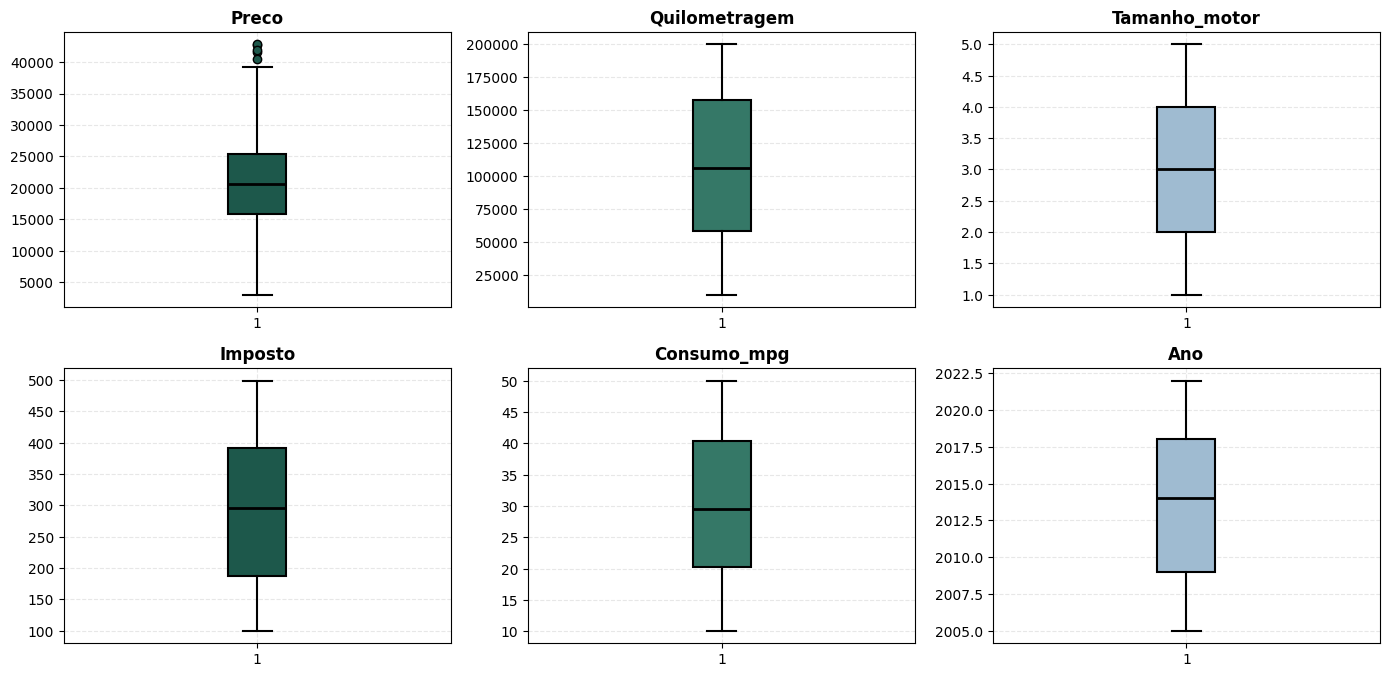

In [76]:
paleta = ['#1d584b', '#357867', '#9fbbd1',]

colunas_numericas = ['preco', 'quilometragem', 'tamanho_motor', 'imposto', 'consumo_mpg', 'ano']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, coluna in enumerate(colunas_numericas):
    cor_atual = paleta[i % len(paleta_verde_azul)]

    axes[i].boxplot(
        df_carros[coluna].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=cor_atual, color='#000000', linewidth=1.5),
        whiskerprops=dict(color='#000000', linewidth=1.5),
        capprops=dict(color='#000000', linewidth=1.5),
        medianprops=dict(color='#000000', linewidth=2),
        flierprops=dict(
            markerfacecolor=cor_atual, markeredgecolor='#000000', marker='o'
        ),
    )

    axes[i].set_title(coluna.capitalize(), fontsize=12, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.3)

for j in range(len(colunas_numericas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [77]:
def detectar_outliers(df, coluna):
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    return len(outliers), limite_inferior, limite_superior

for coluna in colunas_numericas:
    qtd, inf, sup = detectar_outliers(df_carros, coluna)
    print(f'{coluna}: {qtd} outliers (limites: {inf:.2f} a {sup:.2f})')

preco: 5 outliers (limites: 1523.25 a 39691.25)
quilometragem: 0 outliers (limites: -91481.12 a 306957.88)
tamanho_motor: 0 outliers (limites: -1.00 a 7.00)
imposto: 0 outliers (limites: -118.38 a 698.62)
consumo_mpg: 0 outliers (limites: -9.85 a 70.55)
ano: 0 outliers (limites: 1995.50 a 2031.50)


In [78]:
q1_preco = df_carros['preco'].quantile(0.25)
q3_preco = df_carros['preco'].quantile(0.75)
iqr_preco = q3_preco - q1_preco
limite_inferior_preco = q1_preco - 1.5 * iqr_preco
limite_superior_preco = q3_preco + 1.5 * iqr_preco
outliers_preco = df_carros[(df_carros['preco'] < limite_inferior_preco) | (df_carros['preco'] > limite_superior_preco)]
display(outliers_preco.sort_values('preco'))

,id,marca,modelo,ano,preco,quilometragem,tamanho_motor,tipo_combustivel,transmissao,portas,cor,imposto,consumo_mpg,data_venda
709,710,BMW,Model C,2013,40463,80021,2.8,Electric,Manual,5,Red,359,48.4,2021-09-13
251,252,BMW,Model C,2008,41610,127305,3.7,Hybrid,Automatic,2,White,382,32.4,2022-01-07
949,950,Honda,Model B,2018,41853,134954,4.4,Diesel,Automatic,5,Black,330,48.6,2020-03-22
324,325,BMW,Model B,2022,42782,179934,3.2,Hybrid,Manual,4,White,404,10.8,2020-05-30
840,841,Chevrolet,Model B,2018,42823,166488,1.8,Hybrid,Manual,5,Blue,369,49.5,2022-02-02


### **Interpretação dos Resultados**

A identificação de outliers foi feita pelo método do intervalo interquartil (IQR).

Foram identificados 5 outliers (0,5% da base), todos acima do limite superior. O limite inferior não foi acionado, já que o menor preço registrado é R$ 3.000.

Decisão: manter os registros

O maior valor observado (R$ 42.823) está apenas 7,9% acima do limite superior, sem indícios de erro de digitação. Não há valores zerados, negativos ou fora de ordem de grandeza.

A remoção eliminaria a cauda superior da distribuição sem ganho analítico. Para a estatística descritiva, o uso da mediana já reduz a influência de valores extremos.

# QUESTÃO 01. Análise de Correlação

**Calcule a correlação entre as variáveis numéricas e o preço do carro**

Observação: a base possui exatamente cinco variáveis numéricas preditoras (ano, quilometragem, tamanho_motor, consumo_mpg e imposto). As colunas `id` (apenas identificador) e `portas` foram excluídas: `portas` é numérica, mas assume poucos valores distintos (2, 4 e 5), comportando-se como categórica, o que a torna inadequada para histograma, dispersão e regressão contínua. Portanto, "as 5 mais correlacionadas" correspondem a todas as variáveis numéricas preditoras da base.

In [79]:
df_carros['portas'].value_counts()

,count
portas,
4,268
5,254
3,251
2,227


In [80]:
correlacao_preco = df_carros[
    ['preco', 'ano', 'quilometragem','tamanho_motor','consumo_mpg','imposto']
    ].corr()['preco'].sort_values(ascending=False)

print(correlacao_preco)

preco            1.000000
quilometragem    0.011115
imposto          0.009043
tamanho_motor   -0.000181
consumo_mpg     -0.008201
ano             -0.033064
Name: preco, dtype: float64


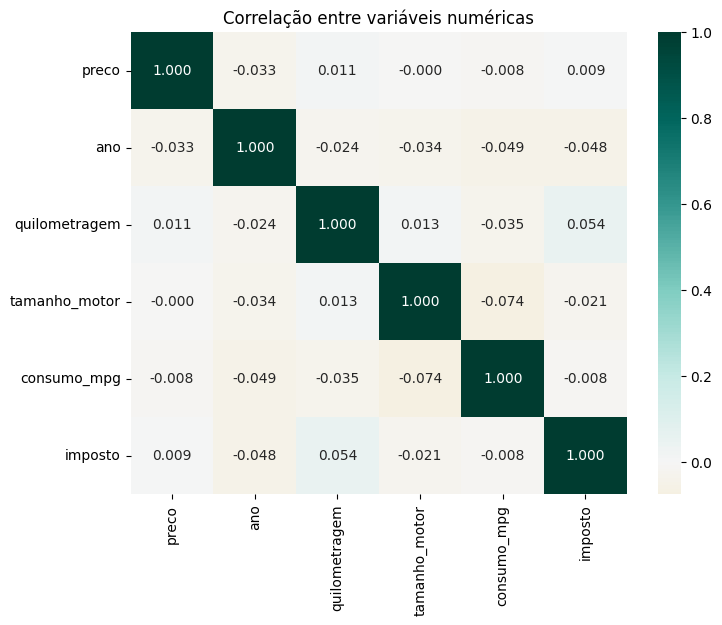

In [81]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df_carros[['preco','ano','quilometragem','tamanho_motor','consumo_mpg','imposto']].corr(),
    annot=True, cmap='BrBG', center=0, fmt='.3f'
)
plt.title('Correlação entre variáveis numéricas')
plt.show()

**Resposta**

Nenhuma variável numérica apresenta correlação relevante com o preço. Todos os coeficientes ficam muito próximos de zero. Foi realizado o cálculo o coeficiente de correlação de Pearson ($r$), onde:

* $+1$: Correlação linear positiva perfeita.

* $0$: Ausência de relação linear.  

* $-1$: Correlação linear negativa perfeita.


valores abaixo de 0,1 em módulo indicam correlação desprezível.


**Quais variáveis estão mais correlacionadas com o preço? E quais estão menos correlacionadas?**

In [82]:
correlacao_preco = df_carros[['preco', 'ano', 'quilometragem','tamanho_motor','consumo_mpg','imposto']].corr()['preco']

# remove o próprio preço e ordena pela força (valor absoluto)
correlacao_preco = correlacao_preco.drop('preco')
correlacao_ordenada = correlacao_preco.reindex(correlacao_preco.abs().sort_values(ascending=False).index)

print('Medição da correlação das 5 variáveis numéricas relevantes: ')
print(correlacao_ordenada)

Medição da correlação das 5 variáveis numéricas relevantes: 
ano             -0.033064
quilometragem    0.011115
imposto          0.009043
consumo_mpg     -0.008201
tamanho_motor   -0.000181
Name: preco, dtype: float64


### **Interpretação dos Resultados**

As variáveis numéricas preditoras da base são exatamente cinco (ano, quilometragem, tamanho_motor, consumo_mpg e imposto), por isso todas foram incluídas na análise.

**Top variáveis com maior correlação:**
1. **ano** ($\vert{}-0{,}033064\vert{}$)
2. **quilometragem** ($\vert{}0{,}011115\vert{}$)
3. **imposto** ($\vert{}0{,}009043\vert{}$)
4. **consumo_mpg** ($\vert{}-0{,}008201\vert{}$)
5. **tamanho_motor** (aproximadamente $-0{,}000181$, o que indica ausência praticamente total de relação linear direta com o preço nesta base).


> Todas as variáveis numéricas apresentam **correlações lineares extremamente baixas** (próximas de zero) com o preço nesta base de dados específica. Isso indica que modelos lineares simples baseados apenas nessas variáveis numéricas individuais terão baixo poder preditivo ($R^2$ baixo).

### O que podemos concluir?

A análise de correlação de Pearson ($r$) busca identificar a força e a direção de relações lineares entre as variáveis numéricas e o preço do veículo (preco). Como padrão geral, valores entre $-1$ e $+1$ indicam a intensidade dessa relação.

### 1. **ano ($r = -0{,}033064$)**

* **O que o número indica:** Correlação negativa **extremamente fraca** e contraintuitiva.
* **Conclusão:** Teoricamente, carros mais novos deveriam ter preços maiores. O fato de o resultado indicar o oposto (e com valor próximo de zero) evidencia que **o ano do carro sozinho não explica o valor de venda**. Isso ocorre porque o preço final depende fortemente da categoria do veículo (ex.: um carro de luxo de 2010 pode custar muito mais que um popular de 2022).


### 2. **quilometragem`($r = +0{,}011115$)**

* **O que o número indica:** Correlação positiva **virtualmente nula** e contraintuitiva.
* **Conclusão:** No mercado tradicional, maior quilometragem reduz o valor do veículo. O resultado positivo e próximo de zero sugere que os dados estão mesclados com categorias distintas (ex.: SUVs e carros *premium* muito rodados ainda mantendo preços superiores a carros populares pouco rodados). A quilometragem isolada **não possui relação linear clara com o preço nesta base**.


### 3. **imposto ($r = +0{,}009043$)**

* **O que o número indica:** Correlação positiva **virtualmente nula**.
* **Conclusão:** Os custos de taxas anuais/impostos associados ao veículo não possuem associação linear direta com o preço de revenda. Carros em todas as faixas de preço apresentam taxas anuais variadas.


### 4. **consumo_mpg ($r = -0{,}008201$)**

* **O que o número indica:** Correlação negativa **virtualmente nula**.
* **Conclusão:** A eficiência energética/autonomia do veículo (economia de combustível) não afeta diretamente o preço de venda nesta base. Veículos econômicos e gastões estão distribuídos de forma homogênea entre os diferentes preços.


### 5. **tamanho_motor ($r = -0{,}000181$)**

* **O que o número indica:** Correlação **completamente nula**.
* **Conclusão:** Foi a variável menos correlacionada da base. O tamanho do motor não possui **nenhuma relação linear direta** com o preço do veículo quando analisado de forma isolada.



**Conclusão:** Nenhuma variável numérica individual é capaz de explicar o preço dos carros através de um modelo linear simples.


# QUESTÃO 02. Análise das 5 Variáveis Mais Correlacionadas

*Para as cinco variáveis com maior correlação com o preço.*

**1. Plote histograma e boxplot de cada variável.**

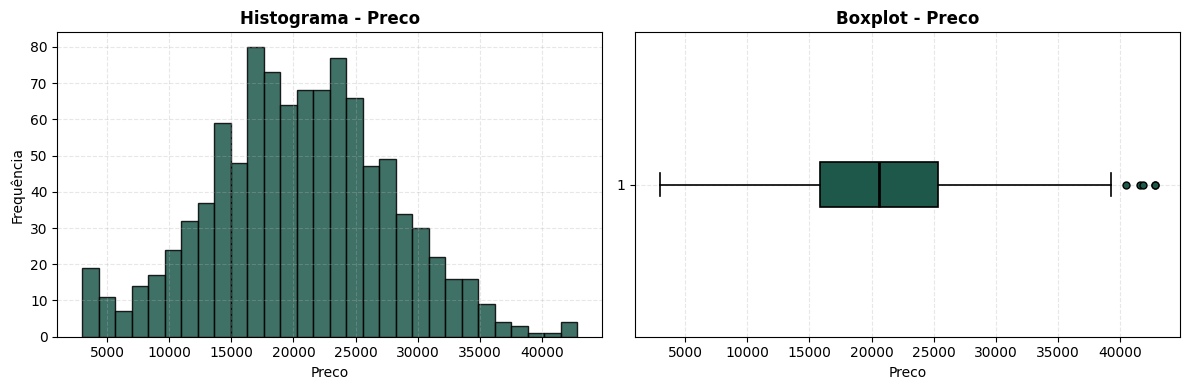

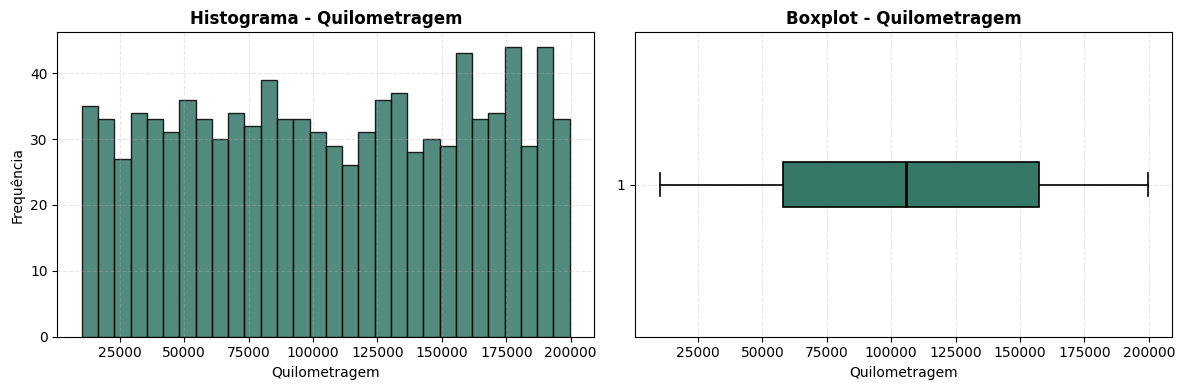

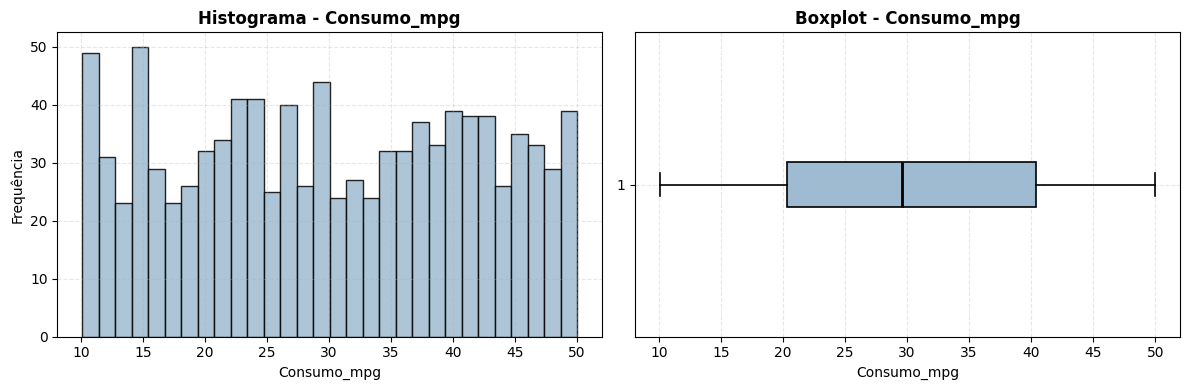

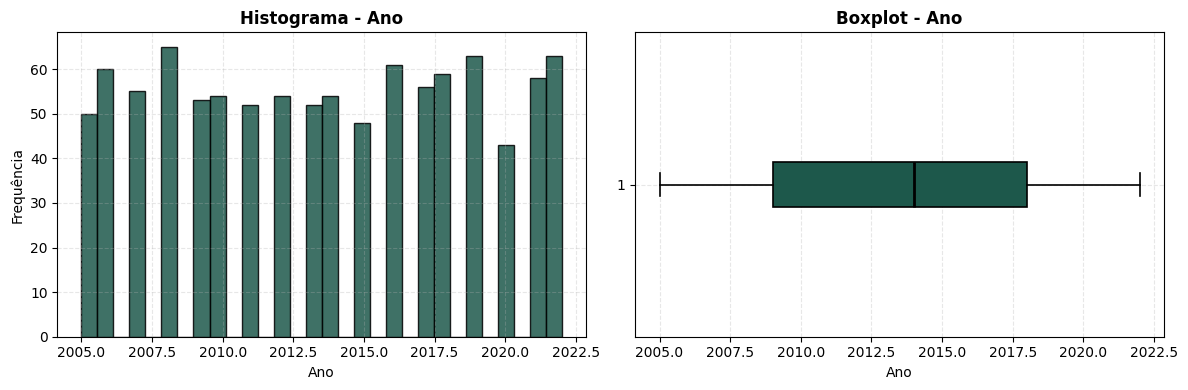

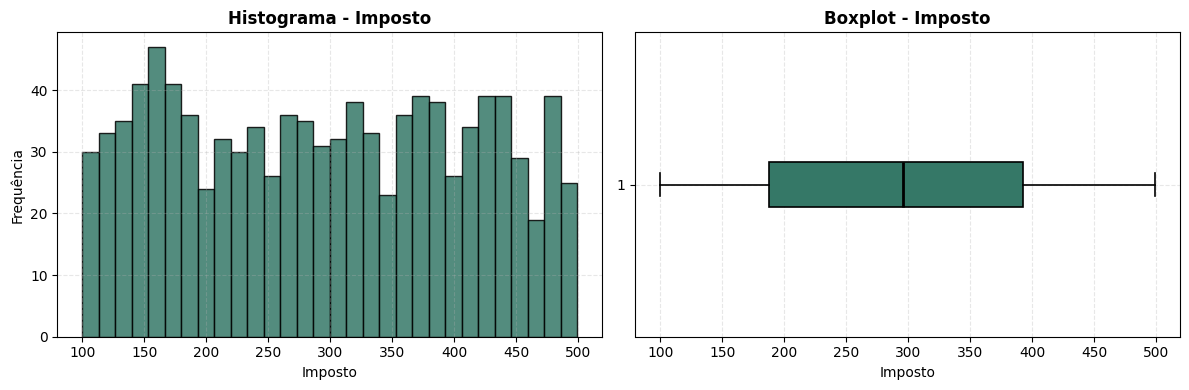

In [83]:
paleta = ['#1d584b', '#357867', '#9fbbd1']

variaveis_numericas = ['preco', 'quilometragem', 'consumo_mpg', 'ano', 'imposto']

for i, coluna in enumerate(variaveis_numericas):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    cor_principal = paleta[i % len(paleta)]

    # Histograma
    ax1.hist(
        df_carros[coluna].dropna(),
        bins=30,
        color=cor_principal,
        edgecolor='black',
        alpha=0.85
    )
    ax1.set_title(f'Histograma - {coluna.capitalize()}', fontsize=12, fontweight='bold')
    ax1.set_xlabel(coluna.capitalize())
    ax1.set_ylabel('Frequência')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # Boxplot
    ax2.boxplot(
        df_carros[coluna].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(
            facecolor=cor_principal,
            color='black',
            linewidth=1.2
        ),
        whiskerprops=dict(
            color='black',
            linewidth=1.2
        ),
        capprops=dict(
            color='black',
            linewidth=1.2
        ),
        medianprops=dict(
            color='black',
            linewidth=2
        ),
        flierprops=dict(
            marker='o',
            markerfacecolor=cor_principal,
            markeredgecolor='black',
            markersize=5
        ),
    )

    ax2.set_title(f'Boxplot - {coluna.capitalize()}', fontsize=12, fontweight='bold')
    ax2.set_xlabel(coluna.capitalize())
    ax2.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

As variáveis se dividem em dois padrões. Quilometragem, consumo e imposto têm distribuição aproximadamente uniforme: as barras do histograma ficam parecidas ao longo de toda a faixa, sem concentração em nenhum ponto, com kurtosis próxima de 1,2 negativa, característica da distribuição uniforme. Já o preço tem distribuição aproximadamente normal, em formato de sino, concentrado em torno da mediana de R$ 20.622.

Os boxplots mostram caixas largas e medianas centralizadas em todas as variáveis, o que indica simetria, já que a assimetria ficou próxima de zero em todos os casos. Quanto a valores extremos, apenas o preço apresenta outliers, os 5 já discutidos, todos na ponta superior. As demais variáveis não têm nenhum.

Vale notar que a forma individual das distribuições é razoável e o preço, em particular, se comporta como esperado. O que chama atenção nesta base não é a distribuição de cada variável isolada, e sim a ausência de relação entre elas, confirmada pela análise de correlação.

**2. Plote o scatterplot (gráfico de dispersão), com price no eixo Y e a variável no eixo X.**

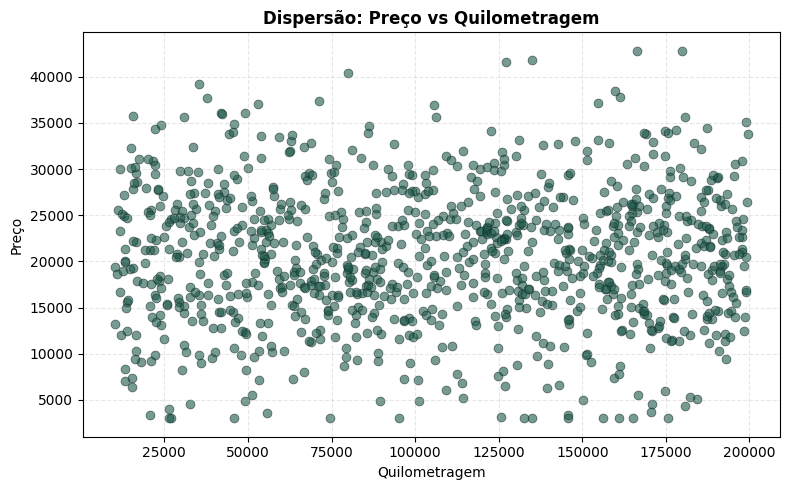

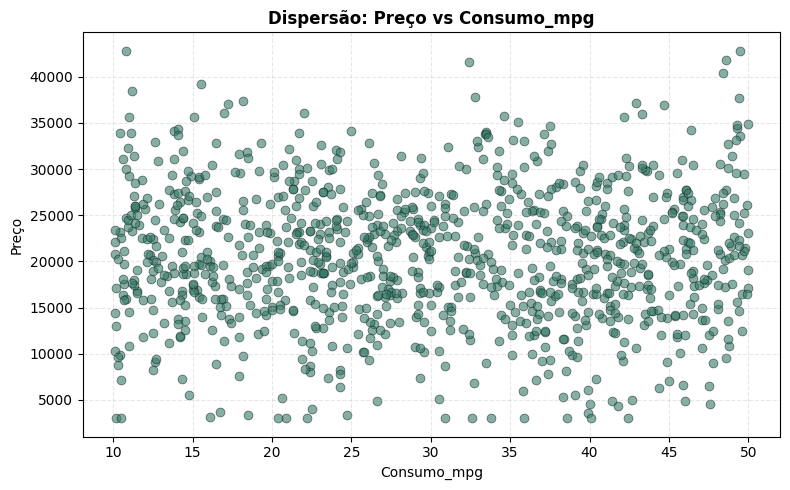

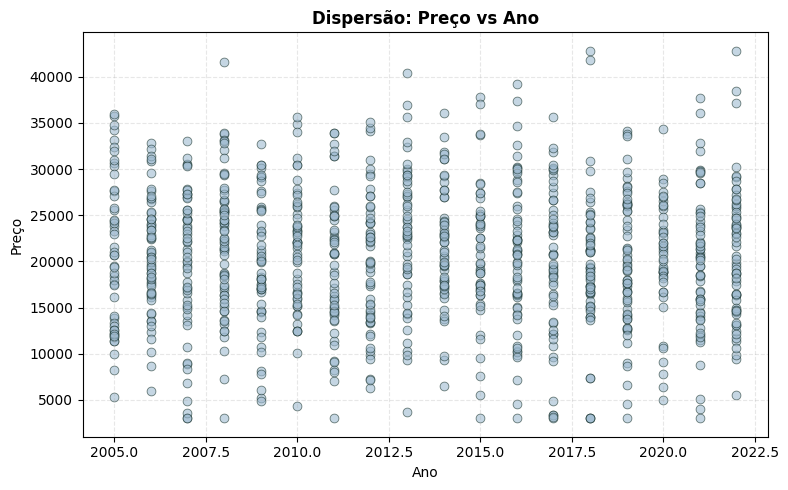

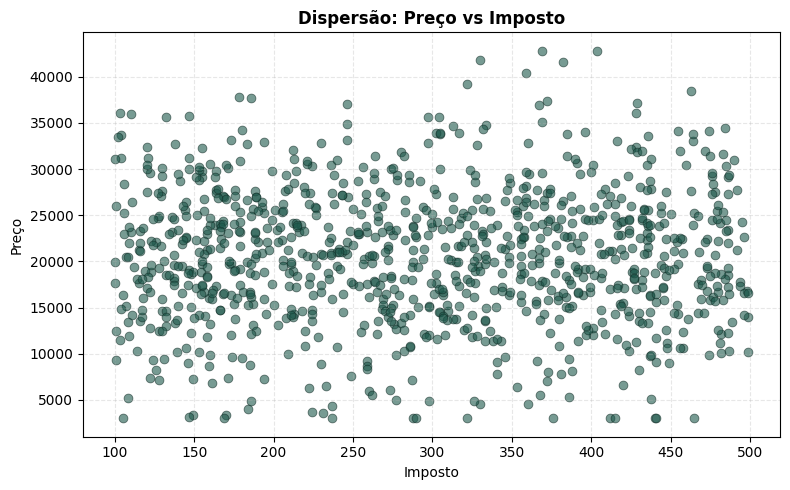

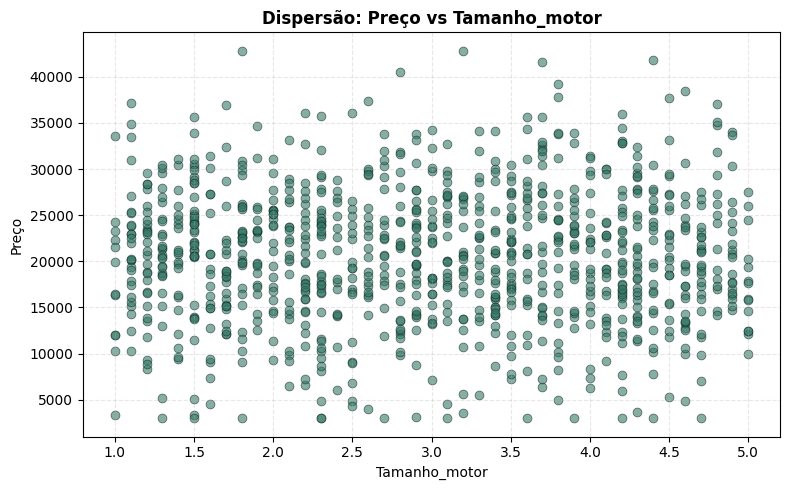

In [84]:
paleta = ['#1d584b', '#357867', '#9fbbd1',]

variaveis_x = ['quilometragem', 'consumo_mpg', 'ano', 'imposto', 'tamanho_motor']

for i, coluna in enumerate(variaveis_x):
    plt.figure(figsize=(8, 5))

    cor_atual = paleta[i % len(paleta_verde_azul)]

    plt.scatter(
        df_carros[coluna],
        df_carros['preco'],
        color=cor_atual,
        edgecolor='#112c26',
        linewidth=0.6,
        alpha=0.6,
        s=40,
    )

    plt.title(
        f'Dispersão: Preço vs {coluna.capitalize()}',
        fontsize=12,
        fontweight='bold',
    )
    plt.xlabel(coluna.capitalize(), fontsize=10)
    plt.ylabel('Preço', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

Cada gráfico coloca o preço no eixo Y e uma variável no eixo X, para enxergar visualmente a relação entre elas. Em todos, o resultado é o mesmo: uma nuvem de pontos espalhada por toda a área, sem tendência de subida ou descida.

Isso é a tradução visual das correlações próximas de zero calculadas antes. Se houvesse relação, os pontos formariam um padrão, como uma faixa inclinada para cima em preço versus ano (carro mais novo, mais caro) ou para baixo em preço versus quilometragem (mais rodado, mais barato). Nenhum desses padrões aparece: os pontos se distribuem de forma homogênea, indicando que o valor de X não ajuda a prever o preço.

A leitura conjunta, correlação numérica perto de zero somada à nuvem sem formato nos gráficos, dá uma evidência sólida de que não existe relação linear entre as variáveis e o preço nesta base.

**3. Faça uma regressão linear simples, utilizando cada variável como preditora (X) e o preço como resposta (Y). Interprete os coeficientes e o R²**


In [85]:
variaveis_x = ['ano', 'quilometragem', 'consumo_mpg', 'imposto', 'tamanho_motor']

for coluna in variaveis_x:
    X = df_carros[[coluna]]
    y = df_carros['preco']

    modelo = LinearRegression().fit(X, y)
    r2 = r2_score(y, modelo.predict(X))

    print(f'{coluna}:')
    print(f'  coeficiente = {modelo.coef_[0]:.4f}')
    print(f'  intercepto  = {modelo.intercept_:.2f}')
    print(f'  R²          = {r2:.5f}\n')

ano:
  coeficiente = -45.7295
  intercepto  = 112603.79
  R²          = 0.00109

quilometragem:
  coeficiente = 0.0015
  intercepto  = 20369.96
  R²          = 0.00012

consumo_mpg:
  coeficiente = -5.0667
  intercepto  = 20676.80
  R²          = 0.00007

imposto:
  coeficiente = 0.5703
  intercepto  = 20356.92
  R²          = 0.00008

tamanho_motor:
  coeficiente = -1.1414
  intercepto  = 20528.30
  R²          = 0.00000



As regressões confirmam numericamente o que a correlação, os scatterplots e a matriz já indicaram: não existe relação linear entre as variáveis e o preço nesta base. Os coeficientes são próximos de zero (e alguns com sinal contrário ao esperado na realidade), e os R² são desprezíveis. Isso significa que um modelo linear não consegue prever o preço a partir dessas variáveis (resultado coerente com dados que aparentam ter sido gerados de forma independente). O baixo desempenho, portanto, não é uma falha do modelo, mas um reflexo da própria estrutura (ou ausência de estrutura) dos dados.

---

## Análises Complementares

O enunciado tratou apenas das variáveis numéricas. As análises abaixo exploram as variáveis categóricas e um modelo múltiplo, para verificar se algum outro fator explica o preço.

Como a variável 'portas' se comporta como uma variável categórica, vamos tratá-la na base e adicioná-la aos complementos

In [86]:
df_carros['portas_categoria'] = df_carros['portas'].map({
    2: 'Duas portas',
    3: 'Três portas',
    4: 'Quatro portas',
    5: 'Cinco portas'
})

In [87]:
df_carros.head()

,id,marca,modelo,ano,preco,quilometragem,tamanho_motor,tipo_combustivel,transmissao,portas,cor,imposto,consumo_mpg,data_venda,portas_categoria
0,1,Volkswagen,Model B,2022,23859,94811,3.6,Diesel,Manual,2,Grey,288,39.2,2023-10-11,Duas portas
1,2,Chevrolet,Model A,2008,16953,128028,4.9,Diesel,Manual,5,Red,339,15.3,2021-04-22,Cinco portas
2,3,BMW,Model B,2006,12332,49178,4.1,Diesel,Automatic,4,Red,458,37.2,2020-05-04,Quatro portas
3,4,Chevrolet,Model B,2018,18475,42821,2.7,Hybrid,Manual,5,Silver,486,43.7,2021-06-20,Cinco portas
4,5,Chevrolet,Model C,2017,12129,192799,2.8,Gasoline,Manual,4,Silver,295,19.1,2021-12-06,Quatro portas


**Complemento 1 — Preço médio por variável categórica**

A correlação de Pearson não capta bem variáveis categóricas, como marca, combustível, transmissão, cor e número de portas. Embora portas seja numérica no dataset, ela foi transformada em portas_categoria, pois representa grupos específicos de veículos, como duas, três, quatro ou cinco portas.

In [88]:
for coluna in ['marca', 'tipo_combustivel', 'transmissao', 'cor', 'portas_categoria']:
    print(f'--- Preço médio por {coluna} ---')
    print(df_carros.groupby(coluna)['preco'].mean().sort_values(ascending=False).round(2))
    print()

--- Preço médio por marca ---
marca
Chevrolet     21535.06
Ford          20728.35
Toyota        20438.05
Honda         20172.37
BMW           20170.86
Volkswagen    20023.94
Name: preco, dtype: float64

--- Preço médio por tipo_combustivel ---
tipo_combustivel
Electric    21172.08
Diesel      20695.27
Gasoline    20415.04
Hybrid      19852.12
Name: preco, dtype: float64

--- Preço médio por transmissao ---
transmissao
Manual       20744.68
Automatic    20303.35
Name: preco, dtype: float64

--- Preço médio por cor ---
cor
White     21045.51
Grey      20692.39
Red       20534.13
Black     20450.20
Blue      20364.30
Silver    20048.70
Name: preco, dtype: float64

--- Preço médio por portas_categoria ---
portas_categoria
Cinco portas     20953.46
Quatro portas    20524.88
Duas portas      20316.02
Três portas      20280.14
Name: preco, dtype: float64



/tmp/ipykernel_854/3589721148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_854/3589721148.py:5: UserWarning: 
The palette list has fewer values (3) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


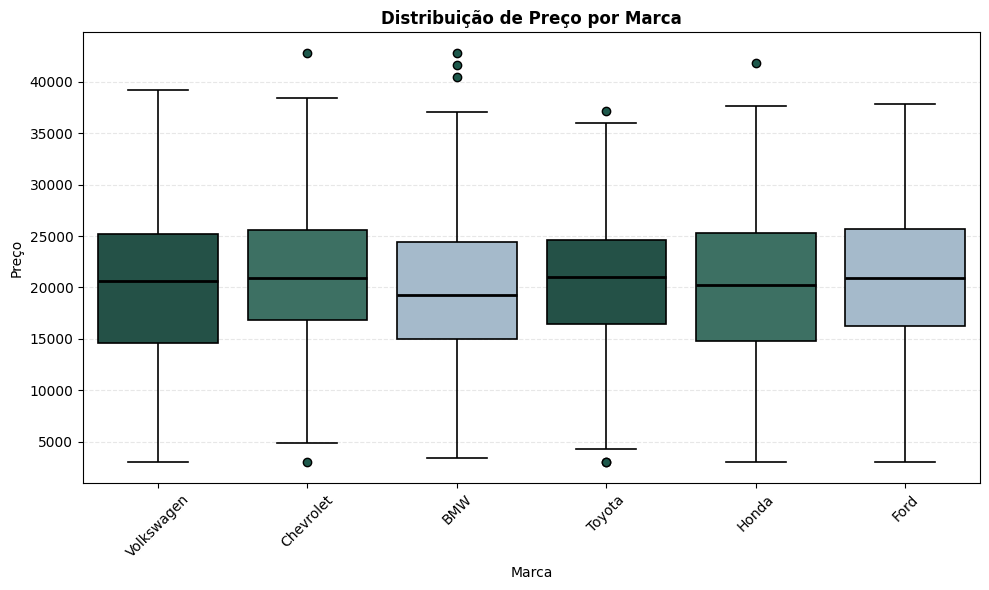

In [89]:
paleta = ['#1d584b', '#357867', '#9fbbd1']

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_carros,
    x='marca',
    y='preco',
    palette=paleta,
    boxprops=dict(
        edgecolor='#000000', linewidth=1.2
    ),
    whiskerprops=dict(color='#000000', linewidth=1.2),
    capprops=dict(color='#000000', linewidth=1.2),
    medianprops=dict(color='#000000', linewidth=2),
    flierprops=dict(
        markerfacecolor='#1d584b', markeredgecolor='#000000', marker='o'
    ),  # Outliers
)

plt.title('Distribuição de Preço por Marca', fontsize=12, fontweight='bold')
plt.xlabel('Marca', fontsize=10)
plt.ylabel('Preço', fontsize=10)
plt.xticks(rotation=45)

plt.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretação**

Os preços médios são praticamente iguais entre todas as categorias. Entre as marcas, a diferença entre a mais cara e a mais barata é de apenas cerca de 7,5%; para combustível, transmissão e cor, as diferenças são ainda menores. Os boxplots por marca ficam alinhados na mesma altura, sem separação visível entre grupos.

Isso confirma, agora também pelas variáveis categóricas, que nenhum fator da base influencia o preço de forma relevante (coerente com a hipótese de dados gerados de forma independente).

In [90]:
# ANOVA: testa se o preço médio difere entre os grupos de cada variável categórica
for coluna in ['marca', 'tipo_combustivel', 'transmissao', 'cor', 'portas_categoria']:
    grupos = [grupo['preco'].values for _, grupo in df_carros.groupby(coluna)]
    f, p = stats.f_oneway(*grupos)
    resultado = 'significativo' if p < 0.05 else 'não significativo'
    print(f'{coluna}: F={f:.3f}, p-valor={p:.4f} -> {resultado}')

marca: F=1.016, p-valor=0.4067 -> não significativo
tipo_combustivel: F=1.431, p-valor=0.2323 -> não significativo
transmissao: F=0.928, p-valor=0.3355 -> não significativo
cor: F=0.341, p-valor=0.8878 -> não significativo
portas_categoria: F=0.454, p-valor=0.7143 -> não significativo


**Interpretação (ANOVA)**

A ANOVA testa se o preço médio difere de forma estatisticamente significativa entre os grupos de cada variável categórica. Foram analisadas as variáveis marca, tipo_combustivel, transmissao, cor e portas_categoria.

Todos os p-valores ficaram acima de 0,05: marca = 0,4067; combustível = 0,2323; transmissão = 0,3355; cor = 0,8878; e portas_categoria = 0,7143. Portanto, não se rejeita a hipótese nula de médias iguais, indicando que nenhuma variável categórica apresentou influência estatisticamente significativa sobre o preço.

Isso confirma estatisticamente o que o agrupamento por médias já sugeria: a variação de preço observada entre as categorias é pequena e provavelmente representa ruído amostral, não um efeito real.

Observação: a ANOVA assume normalidade dos resíduos e homogeneidade de variâncias. Como a base é sintética, esses pressupostos podem não se sustentar plenamente; ainda assim, com p-valores tão altos, nenhuma correção alteraria a conclusão geral.

**Complemento 2 — Regressão linear múltipla**

As regressões simples testaram cada variável isoladamente. Aqui, todas as variáveis numéricas são combinadas em um único modelo, para avaliar se, em conjunto, conseguem explicar o preço.

In [91]:
X = df_carros[['ano', 'quilometragem', 'tamanho_motor', 'consumo_mpg', 'imposto']]
y = df_carros['preco']

modelo_multiplo = LinearRegression().fit(X, y)

print('R² múltiplo:', round(modelo_multiplo.score(X, y), 5))
print('\nCoeficientes:')
for nome, coef in zip(X.columns, modelo_multiplo.coef_):
    print(f'  {nome}: {coef:.4f}')
print(f'\nIntercepto: {modelo_multiplo.intercept_:.2f}')

R² múltiplo: 0.00134

Coeficientes:
  ano: -45.6956
  quilometragem: 0.0013
  tamanho_motor: -12.5113
  consumo_mpg: -5.9153
  imposto: 0.4291

Intercepto: 112489.30


**Interpretação**

O R² do modelo múltiplo é 0,00134 — ou seja, todas as variáveis numéricas juntas explicam apenas cerca de 0,1% da variação do preço. O valor é praticamente idêntico ao das regressões simples, o que mostra que combinar as variáveis não agrega poder preditivo.

**Conclusão geral do desafio:** a ausência de relação entre o preço e qualquer variável foi confirmada por quatro caminhos independentes — correlação de Pearson, gráficos de dispersão, regressões (simples e múltipla) e análise das variáveis categóricas. Um modelo preditivo não é viável nesta base, não por limitação de técnica, mas pela própria natureza dos dados, que aparentam ter sido gerados sem correlação entre as colunas.

A principal limitação é a própria base. Toda a conclusão de que nenhuma variável prevê o preço só se sustenta porque as variáveis desta base não têm relação entre si. Vale a distinção: cada variável, isoladamente, tem uma distribuição realista (o preço, por exemplo, segue uma curva normal plausível). O que falta é a correlação entre elas, que num conjunto real de carros usados existiria: ano e quilometragem quase certamente pesariam no preço. Ou seja, o que descobri aqui diz respeito às relações nos dados, não ao mercado de veículos.